<a href="https://colab.research.google.com/github/quasarblazar/ai/blob/main/10_epoch_t2_brain_tumor_mri_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Import needed libraries

In [1]:
!pip install opendatasets

# Import it
import opendatasets as od

# Download the dataset directly using the URL
od.download("https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: quasarblazar
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset


100%|██████████| 157M/157M [00:00<00:00, 212MB/s]


In [2]:
import os
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
#---------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
#---------------------------------------
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.preprocessing.image import ImageDataGenerator
#---------------------------------------
import warnings
warnings.filterwarnings("ignore")

# 2. Preprocessing

## 2.1 Load data

In [3]:
def train_df(tr_path):
    classes, class_paths = zip(*[(label, os.path.join(tr_path, label, image))
                                 for label in os.listdir(tr_path) if os.path.isdir(os.path.join(tr_path, label))
                                 for image in os.listdir(os.path.join(tr_path, label))])

    tr_df = pd.DataFrame({'Class Path': class_paths, 'Class': classes})
    return tr_df

In [4]:
def test_df(ts_path):
    classes, class_paths = zip(*[(label, os.path.join(ts_path, label, image))
                                 for label in os.listdir(ts_path) if os.path.isdir(os.path.join(ts_path, label))
                                 for image in os.listdir(os.path.join(ts_path, label))])

    ts_df = pd.DataFrame({'Class Path': class_paths, 'Class': classes})
    return ts_df

In [5]:
tr_df = train_df('./brain-tumor-mri-dataset/Training')

In [6]:
tr_df

,Class Path,Class
0,./brain-tumor-mri-dataset/Training/pituitary/T...,pituitary
1,./brain-tumor-mri-dataset/Training/pituitary/T...,pituitary
2,./brain-tumor-mri-dataset/Training/pituitary/T...,pituitary
3,./brain-tumor-mri-dataset/Training/pituitary/T...,pituitary
4,./brain-tumor-mri-dataset/Training/pituitary/T...,pituitary
...,...,...
5595,./brain-tumor-mri-dataset/Training/notumor/Tr-...,notumor
5596,./brain-tumor-mri-dataset/Training/notumor/Tr-...,notumor
5597,./brain-tumor-mri-dataset/Training/notumor/Tr-...,notumor
5598,./brain-tumor-mri-dataset/Training/notumor/Tr-...,notumor


In [7]:
ts_df = test_df('./brain-tumor-mri-dataset/Training')

In [8]:
ts_df

,Class Path,Class
0,./brain-tumor-mri-dataset/Training/pituitary/T...,pituitary
1,./brain-tumor-mri-dataset/Training/pituitary/T...,pituitary
2,./brain-tumor-mri-dataset/Training/pituitary/T...,pituitary
3,./brain-tumor-mri-dataset/Training/pituitary/T...,pituitary
4,./brain-tumor-mri-dataset/Training/pituitary/T...,pituitary
...,...,...
5595,./brain-tumor-mri-dataset/Training/notumor/Tr-...,notumor
5596,./brain-tumor-mri-dataset/Training/notumor/Tr-...,notumor
5597,./brain-tumor-mri-dataset/Training/notumor/Tr-...,notumor
5598,./brain-tumor-mri-dataset/Training/notumor/Tr-...,notumor


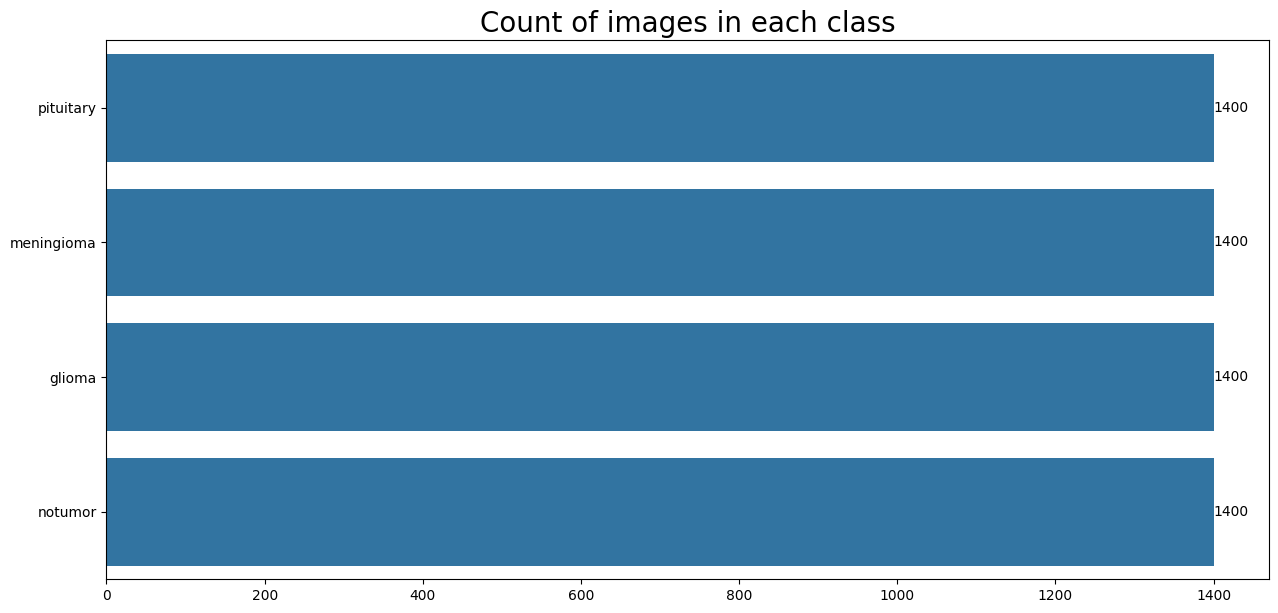

In [9]:
# Count of images in each class in train data
plt.figure(figsize=(15,7))
ax = sns.countplot(data=tr_df , y=tr_df['Class'])

plt.xlabel('')
plt.ylabel('')
plt.title('Count of images in each class', fontsize=20)
ax.bar_label(ax.containers[0])
plt.show()

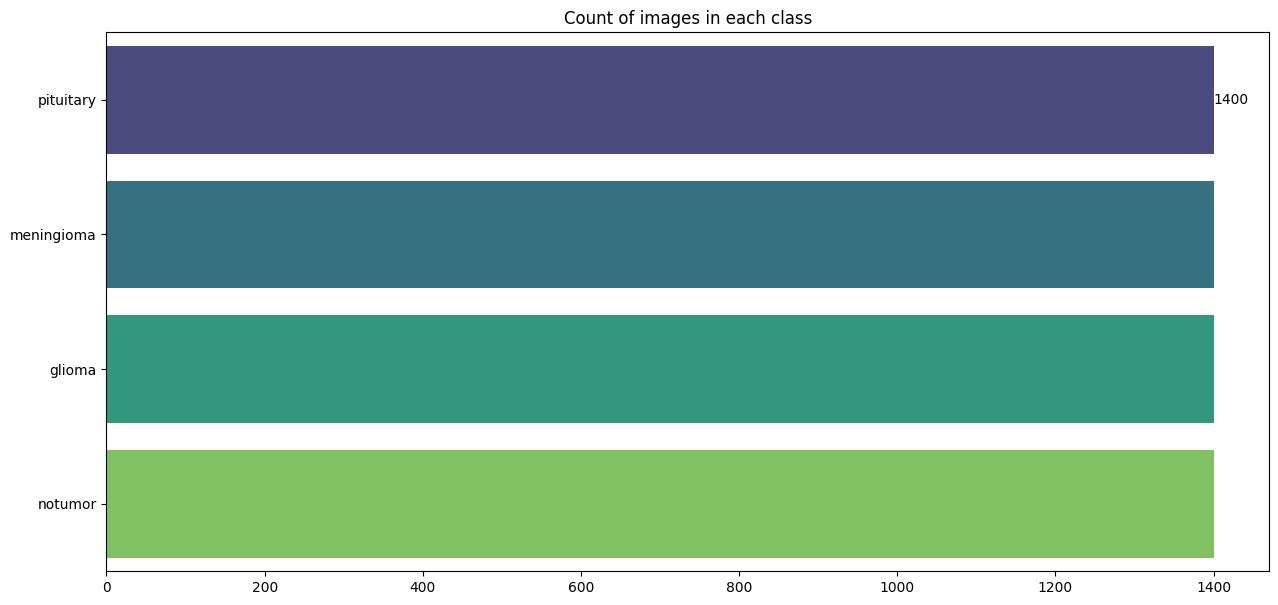

In [10]:
#Count each class in test data
plt.figure(figsize=(15, 7))
ax = sns.countplot(y=ts_df['Class'], palette='viridis')

ax.set(xlabel='', ylabel='', title='Count of images in each class')
ax.bar_label(ax.containers[0])

plt.show()

## 2.2 Split data into train, test, valid

In [11]:
valid_df, ts_df = train_test_split(ts_df, train_size=0.5, random_state=20, stratify=ts_df['Class'])

In [12]:
valid_df

,Class Path,Class
5142,./brain-tumor-mri-dataset/Training/notumor/Tr-...,notumor
5492,./brain-tumor-mri-dataset/Training/notumor/Tr-...,notumor
4232,./brain-tumor-mri-dataset/Training/notumor/Tr-...,notumor
5363,./brain-tumor-mri-dataset/Training/notumor/Tr-...,notumor
318,./brain-tumor-mri-dataset/Training/pituitary/T...,pituitary
...,...,...
759,./brain-tumor-mri-dataset/Training/pituitary/T...,pituitary
3429,./brain-tumor-mri-dataset/Training/glioma/Tr-g...,glioma
2995,./brain-tumor-mri-dataset/Training/glioma/Tr-g...,glioma
4735,./brain-tumor-mri-dataset/Training/notumor/Tr-...,notumor


## 2.3 Data preprocessing

In [13]:
batch_size = 32
img_size = (299, 299)

_gen = ImageDataGenerator(rescale=1/255,
                          brightness_range=(0.8, 1.2))

ts_gen = ImageDataGenerator(rescale=1/255)


tr_gen = _gen.flow_from_dataframe(tr_df, x_col='Class Path',
                                  y_col='Class', batch_size=batch_size,
                                  target_size=img_size)

valid_gen = _gen.flow_from_dataframe(valid_df, x_col='Class Path',
                                     y_col='Class', batch_size=batch_size,
                                     target_size=img_size)

ts_gen = ts_gen.flow_from_dataframe(ts_df, x_col='Class Path',
                                  y_col='Class', batch_size=16,
                                  target_size=img_size, shuffle=False)

Found 5600 validated image filenames belonging to 4 classes.
Found 2800 validated image filenames belonging to 4 classes.
Found 2800 validated image filenames belonging to 4 classes.


## 2.4 Getting samples from data

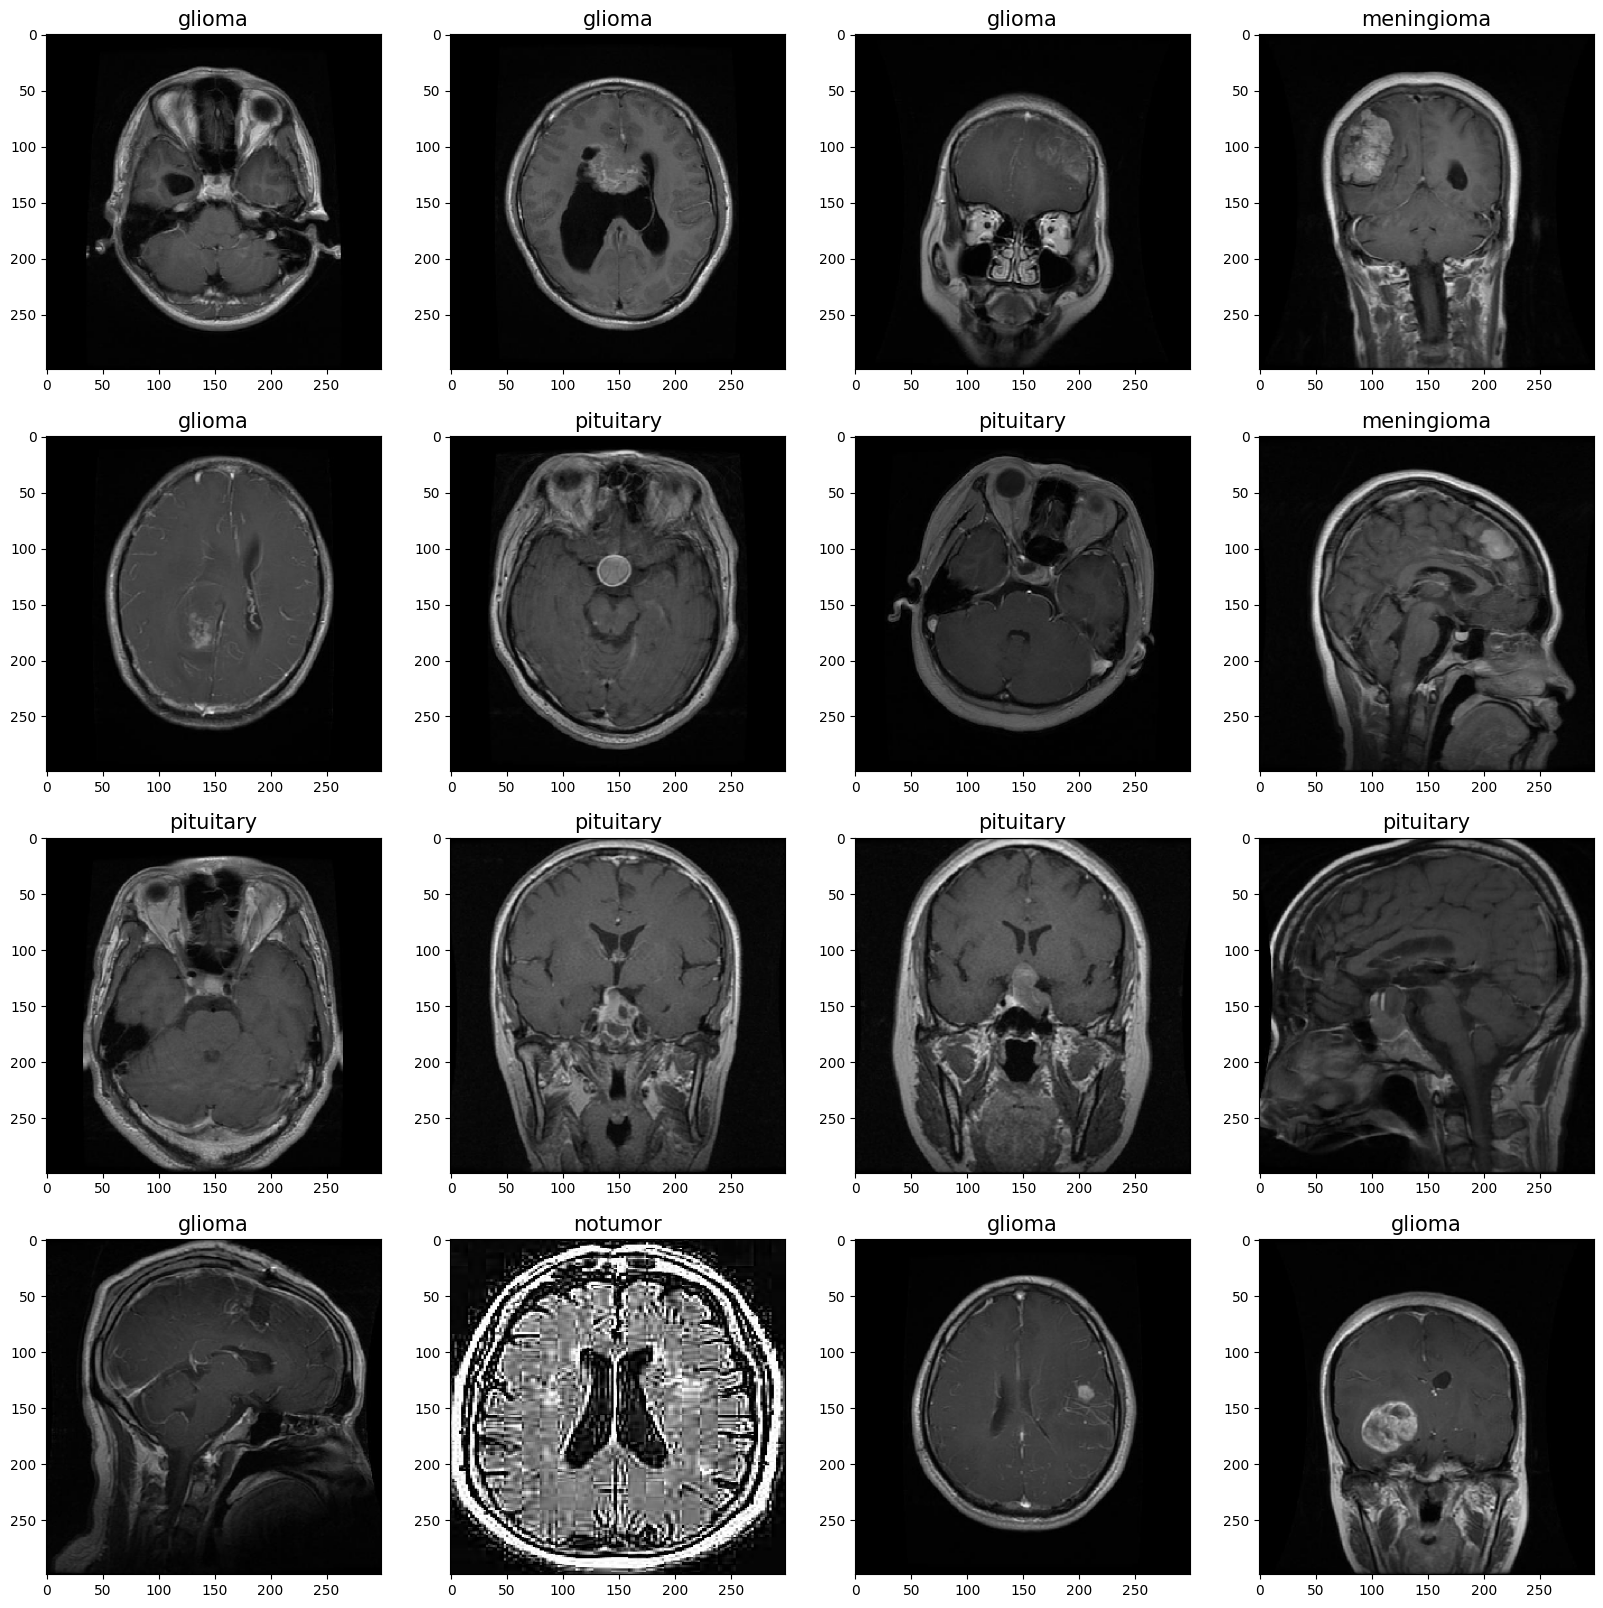

In [14]:
class_dict = tr_gen.class_indices
classes = list(class_dict.keys())
images, labels = next(ts_gen)

plt.figure(figsize=(20, 20))

for i, (image, label) in enumerate(zip(images, labels)):
    plt.subplot(4,4, i + 1)
    plt.imshow(image)
    class_name = classes[np.argmax(label)]
    plt.title(class_name, color='k', fontsize=15)

plt.show()

# 3. Building Deep Learning Model

In [15]:
img_shape=(299,299,3)
base_model = tf.keras.applications.Xception(include_top= False, weights= "imagenet",
                            input_shape= img_shape, pooling= 'max')

# for layer in base_model.layers:
#     layer.trainable = False

model = Sequential([
    base_model,
    Flatten(),
    Dropout(rate= 0.3),
    Dense(128, activation= 'relu'),
    Dropout(rate= 0.25),
    Dense(4, activation= 'softmax')
])

model.compile(Adamax(learning_rate= 0.001),
              loss= 'categorical_crossentropy',
              metrics= ['accuracy',
                        Precision(),
                        Recall()])

model.summary()

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 2048)           │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,124,268 (80.58 MB)

 Trainable params: 21,069,740 (80.37 MB)

 Non-trainable params: 54,528 (213.00 KB)

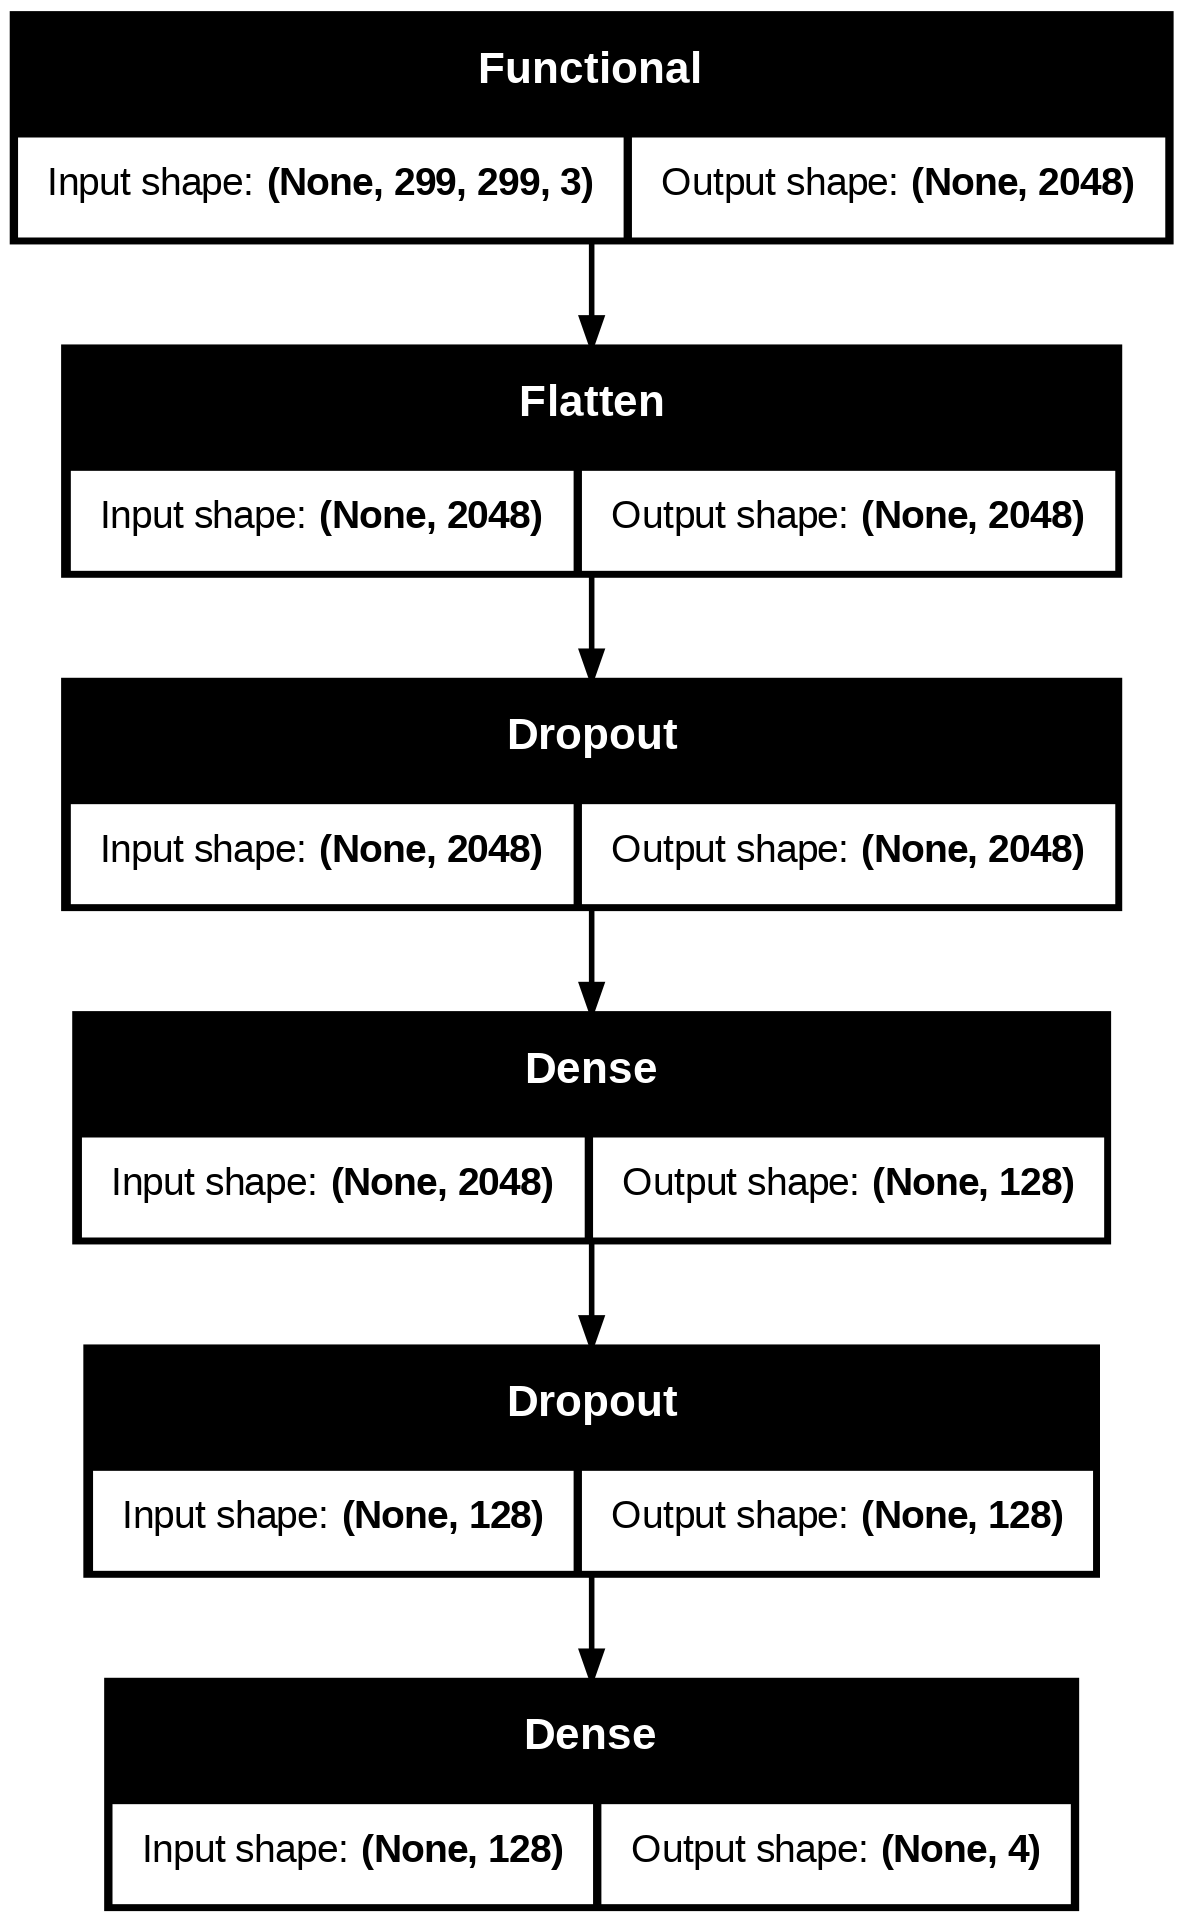

In [16]:
tf.keras.utils.plot_model(model, show_shapes=True)

# 4. Training

In [17]:
hist = model.fit(tr_gen,
                 epochs=10,
                 validation_data=valid_gen,
                 shuffle= False)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 336s 1s/step - accuracy: 0.8948 - loss: 0.3131 - precision: 0.9180 - recall: 0.8657 - val_accuracy: 0.9239 - val_loss: 0.2146 - val_precision: 0.9345 - val_recall: 0.9164
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.9816 - loss: 0.0599 - precision: 0.9833 - recall: 0.9796 - val_accuracy: 0.9632 - val_loss: 0.1013 - val_precision: 0.9638 - val_recall: 0.9604
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - accuracy: 0.9920 - loss: 0.0269 - precision: 0.9921 - recall: 0.9916 - val_accuracy: 0.9950 - val_loss: 0.0175 - val_precision: 0.9954 - val_recall: 0.9946
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.9946 - loss: 0.0184 - precision: 0.9950 - recall: 0.9939 - val_accuracy: 0.9939 - val_loss: 0.0177 - val_precision: 0.9943 - val_recall: 0.9936
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.9950 - loss: 0.0166 - precision: 0.9952 - recall: 0.9948 - val_accuracy: 0.9971 - val_los

In [18]:
hist.history.keys()

dict_keys(['accuracy', 'loss', 'precision', 'recall', 'val_accuracy', 'val_loss', 'val_precision', 'val_recall'])

## 4.1 Visualize model performance

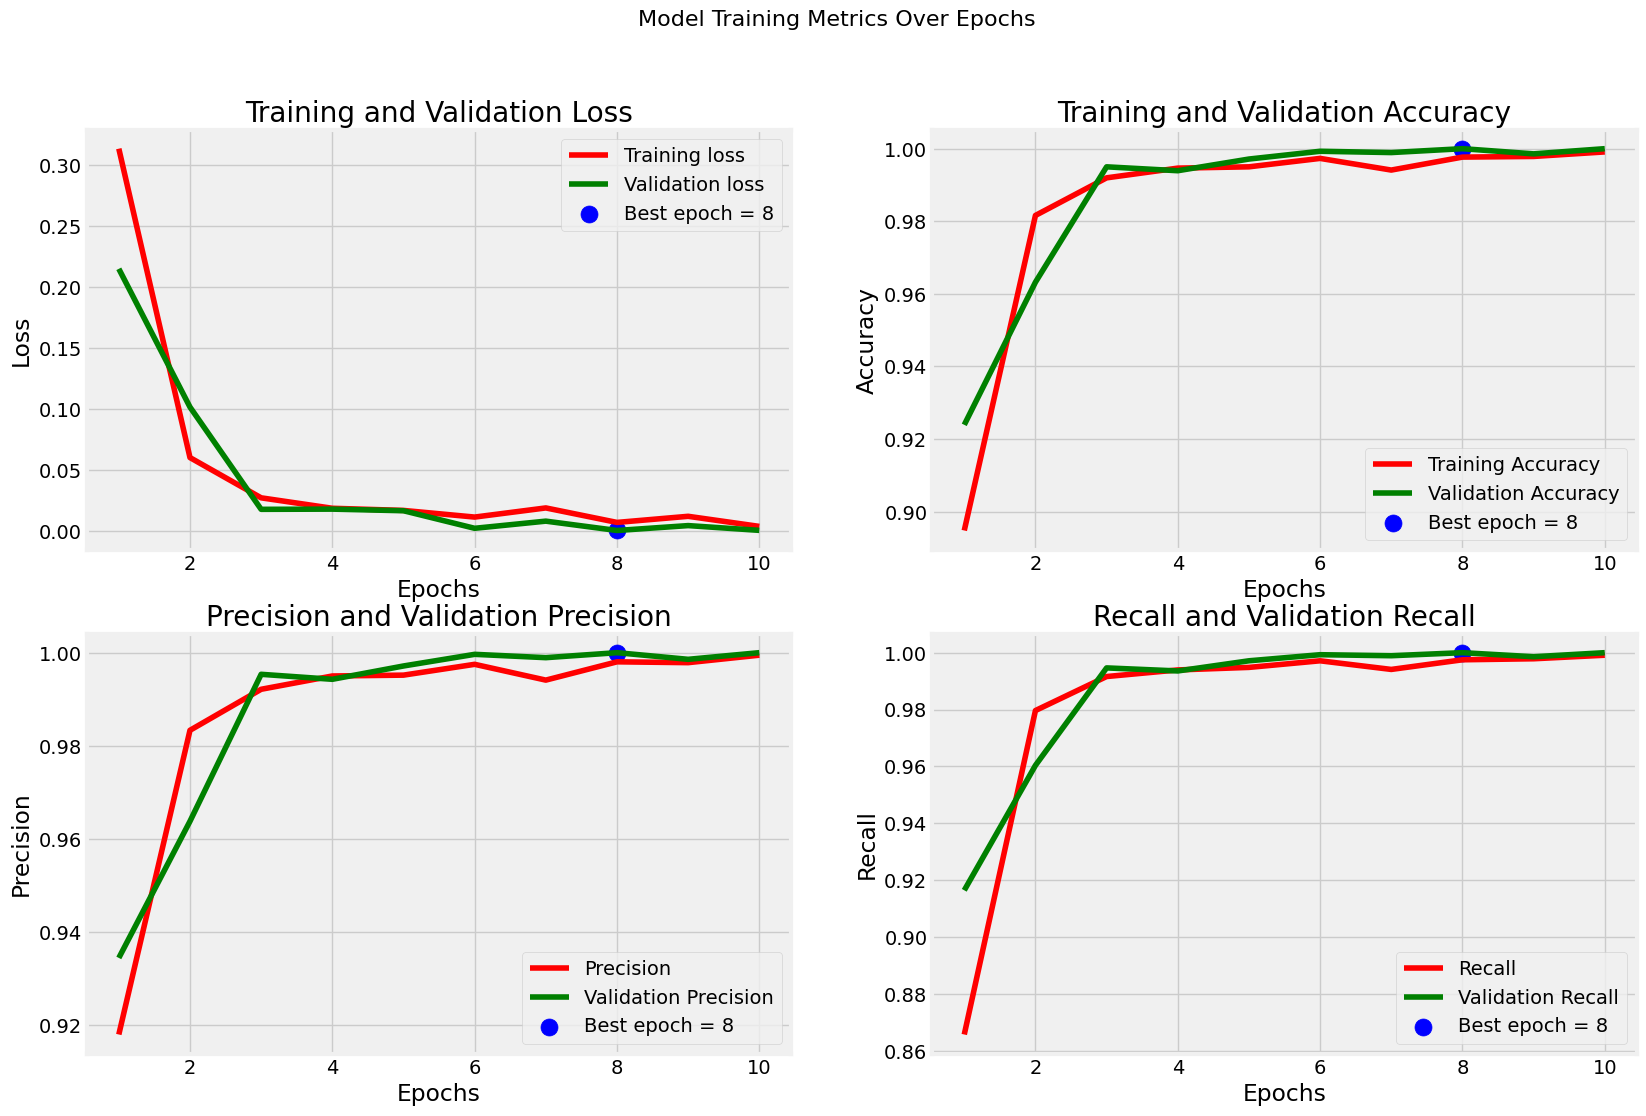

In [19]:
tr_acc = hist.history['accuracy']
tr_loss = hist.history['loss']
tr_per = hist.history['precision']
tr_recall = hist.history['recall']
val_acc = hist.history['val_accuracy']
val_loss = hist.history['val_loss']
val_per = hist.history['val_precision']
val_recall = hist.history['val_recall']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
index_precision = np.argmax(val_per)
per_highest = val_per[index_precision]
index_recall = np.argmax(val_recall)
recall_highest = val_recall[index_recall]

Epochs = [i + 1 for i in range(len(tr_acc))]
loss_label = f'Best epoch = {str(index_loss + 1)}'
acc_label = f'Best epoch = {str(index_acc + 1)}'
per_label = f'Best epoch = {str(index_precision + 1)}'
recall_label = f'Best epoch = {str(index_recall + 1)}'


plt.figure(figsize=(20, 12))
plt.style.use('fivethirtyeight')


plt.subplot(2, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label='Training loss')
plt.plot(Epochs, val_loss, 'g', label='Validation loss')
plt.scatter(index_loss + 1, val_lowest, s=150, c='blue', label=loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label='Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label='Validation Accuracy')
plt.scatter(index_acc + 1, acc_highest, s=150, c='blue', label=acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(Epochs, tr_per, 'r', label='Precision')
plt.plot(Epochs, val_per, 'g', label='Validation Precision')
plt.scatter(index_precision + 1, per_highest, s=150, c='blue', label=per_label)
plt.title('Precision and Validation Precision')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(Epochs, tr_recall, 'r', label='Recall')
plt.plot(Epochs, val_recall, 'g', label='Validation Recall')
plt.scatter(index_recall + 1, recall_highest, s=150, c='blue', label=recall_label)
plt.title('Recall and Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)

plt.suptitle('Model Training Metrics Over Epochs', fontsize=16)
plt.show()

# 5. Testing and Evaluation

## 5.1 Evaluate

In [20]:
train_score = model.evaluate(tr_gen, verbose=1)
valid_score = model.evaluate(valid_gen, verbose=1)
test_score = model.evaluate(ts_gen, verbose=1)

print(f"Train Loss: {train_score[0]:.4f}")
print(f"Train Accuracy: {train_score[1]*100:.2f}%")
print('-' * 20)
print(f"Validation Loss: {valid_score[0]:.4f}")
print(f"Validation Accuracy: {valid_score[1]*100:.2f}%")
print('-' * 20)
print(f"Test Loss: {test_score[0]:.4f}")
print(f"Test Accuracy: {test_score[1]*100:.2f}%")


175/175 ━━━━━━━━━━━━━━━━━━━━ 51s 290ms/step - accuracy: 1.0000 - loss: 1.8127e-04 - precision: 1.0000 - recall: 1.0000
88/88 ━━━━━━━━━━━━━━━━━━━━ 25s 285ms/step - accuracy: 1.0000 - loss: 2.9831e-04 - precision: 1.0000 - recall: 1.0000
175/175 ━━━━━━━━━━━━━━━━━━━━ 23s 132ms/step - accuracy: 1.0000 - loss: 1.5789e-04 - precision: 1.0000 - recall: 1.0000
Train Loss: 0.0002
Train Accuracy: 100.00%
--------------------
Validation Loss: 0.0003
Validation Accuracy: 100.00%
--------------------
Test Loss: 0.0002
Test Accuracy: 100.00%


In [21]:
preds = model.predict(ts_gen)
y_pred = np.argmax(preds, axis=1)

175/175 ━━━━━━━━━━━━━━━━━━━━ 36s 134ms/step


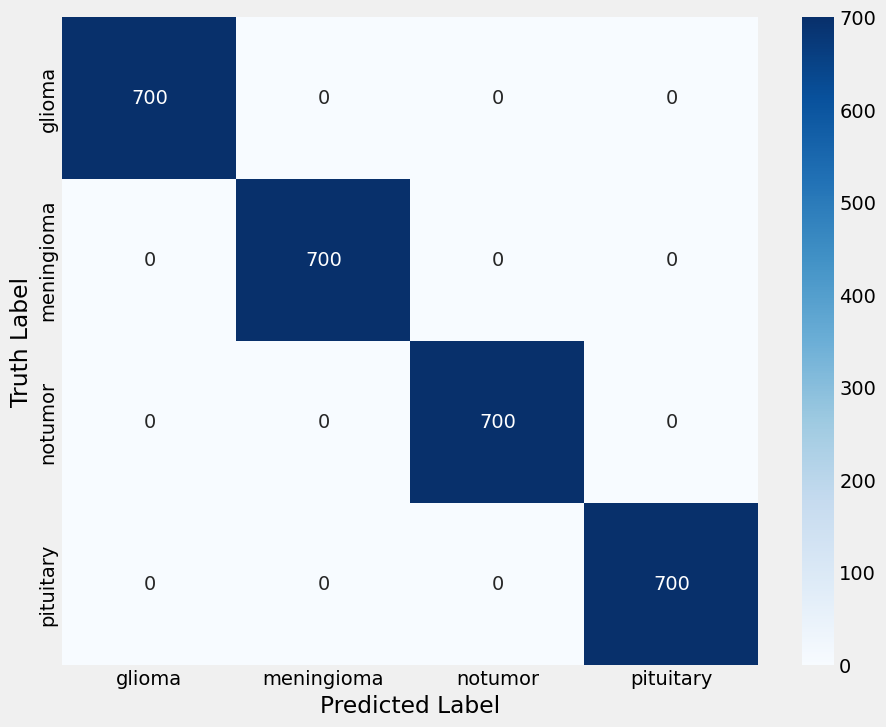

In [22]:
cm = confusion_matrix(ts_gen.classes, y_pred)
labels = list(class_dict.keys())
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('Truth Label')
plt.show()

In [23]:
clr = classification_report(ts_gen.classes, y_pred)
print(clr)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       700
           1       1.00      1.00      1.00       700
           2       1.00      1.00      1.00       700
           3       1.00      1.00      1.00       700

    accuracy                           1.00      2800
   macro avg       1.00      1.00      1.00      2800
weighted avg       1.00      1.00      1.00      2800



## 5.2 Testing

In [24]:
def predict(img_path):
    import numpy as np
    import matplotlib.pyplot as plt
    from PIL import Image
    label = list(class_dict.keys())
    plt.figure(figsize=(12, 12))
    img = Image.open(img_path).convert('RGB') # Convert image to RGB
    resized_img = img.resize((299, 299))
    img = np.asarray(resized_img)
    img = np.expand_dims(img, axis=0)
    img = img / 255
    predictions = model.predict(img)
    probs = list(predictions[0])
    labels = label
    plt.subplot(2, 1, 1)
    plt.imshow(resized_img)
    plt.subplot(2, 1, 2)
    bars = plt.barh(labels, probs)
    plt.xlabel('Probability', fontsize=15)
    ax = plt.gca()
    ax.bar_label(bars, fmt = '%.2f')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step


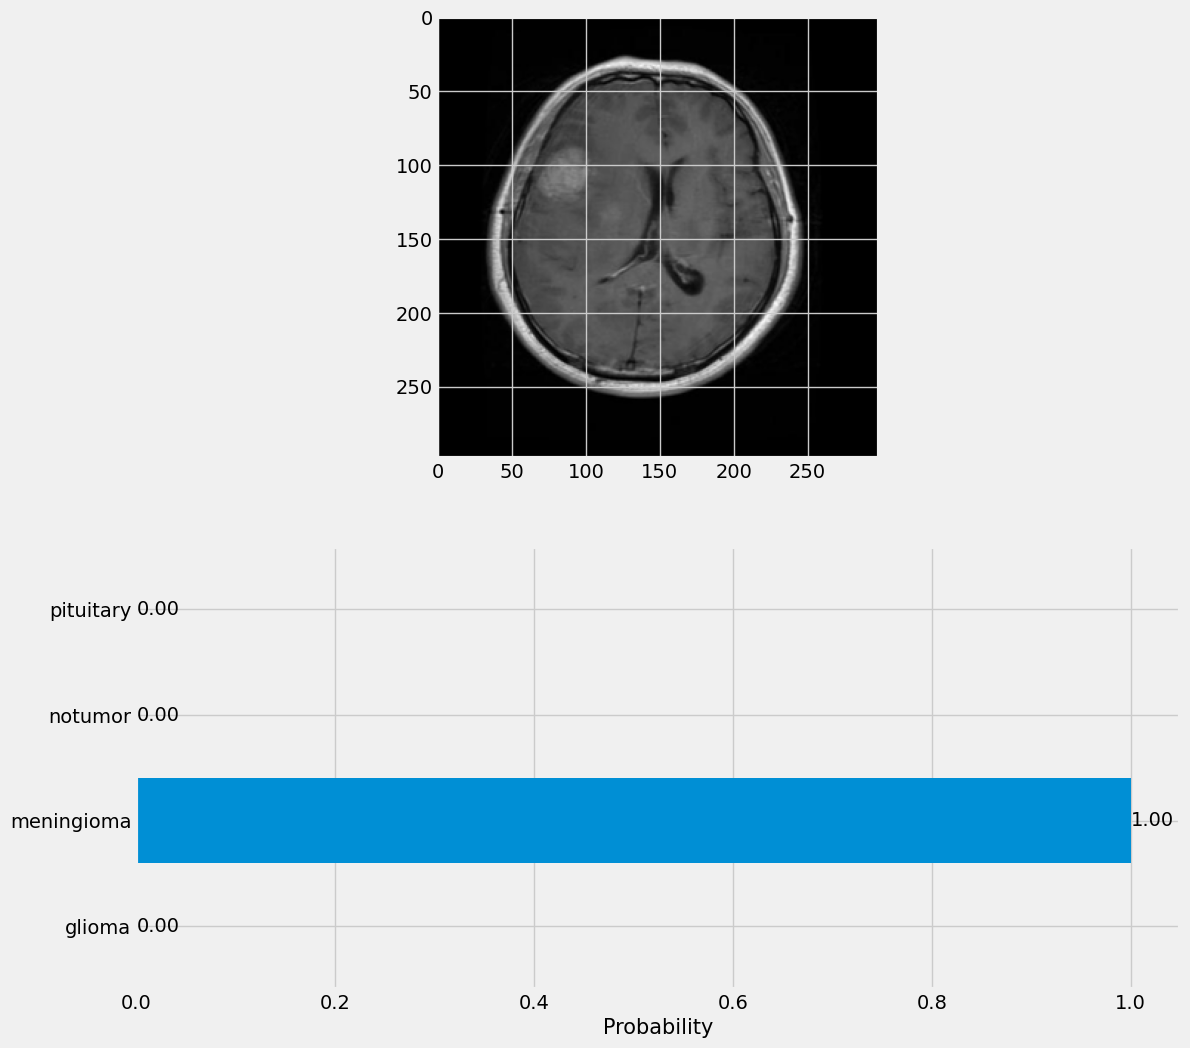

In [25]:
predict('./brain-tumor-mri-dataset/Testing/meningioma/Te-aug-me_26.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


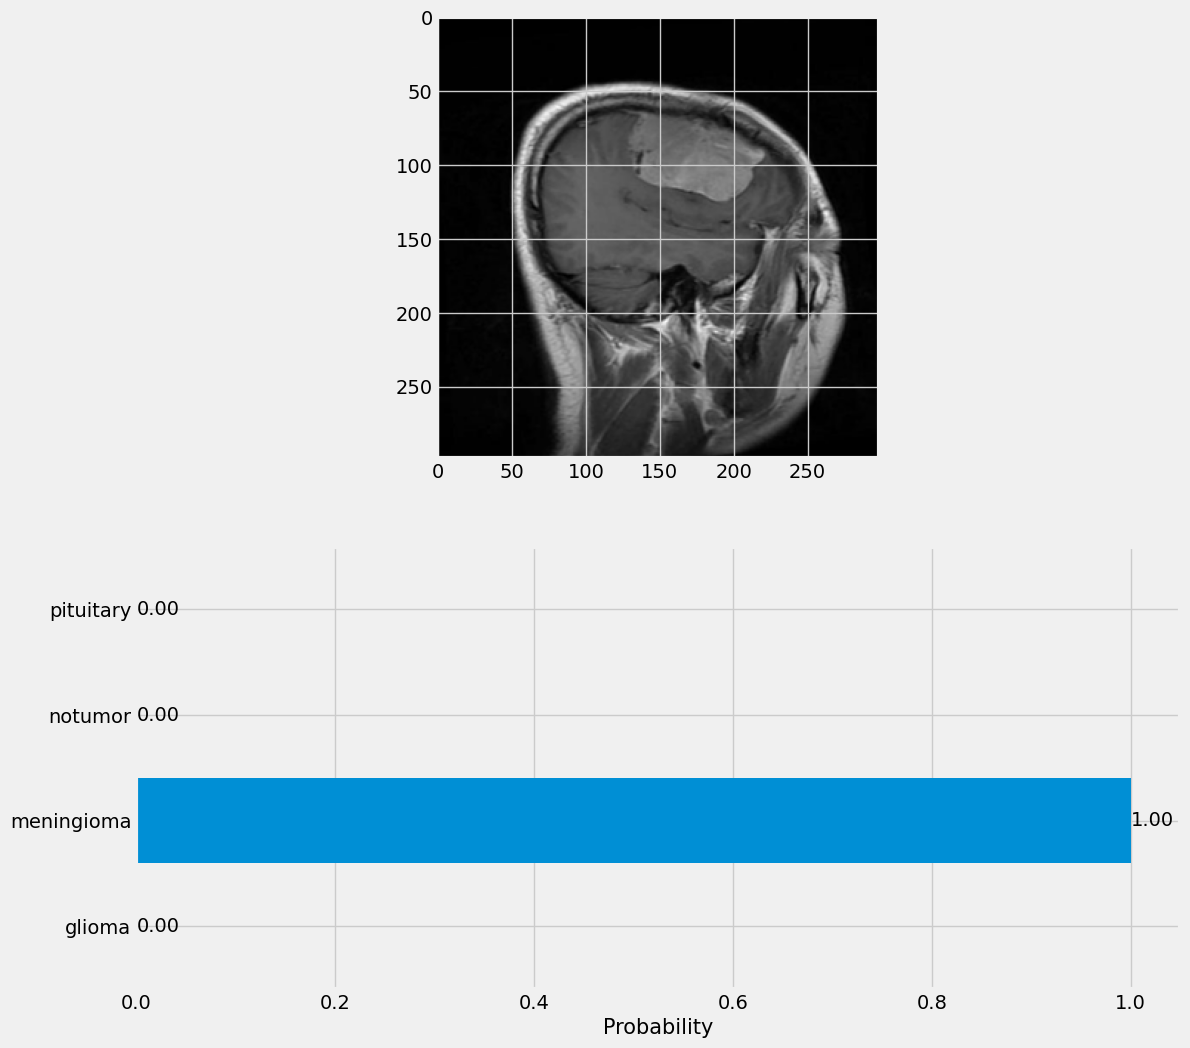

In [26]:
predict('./brain-tumor-mri-dataset/Testing/meningioma/Te-aug-me_15.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


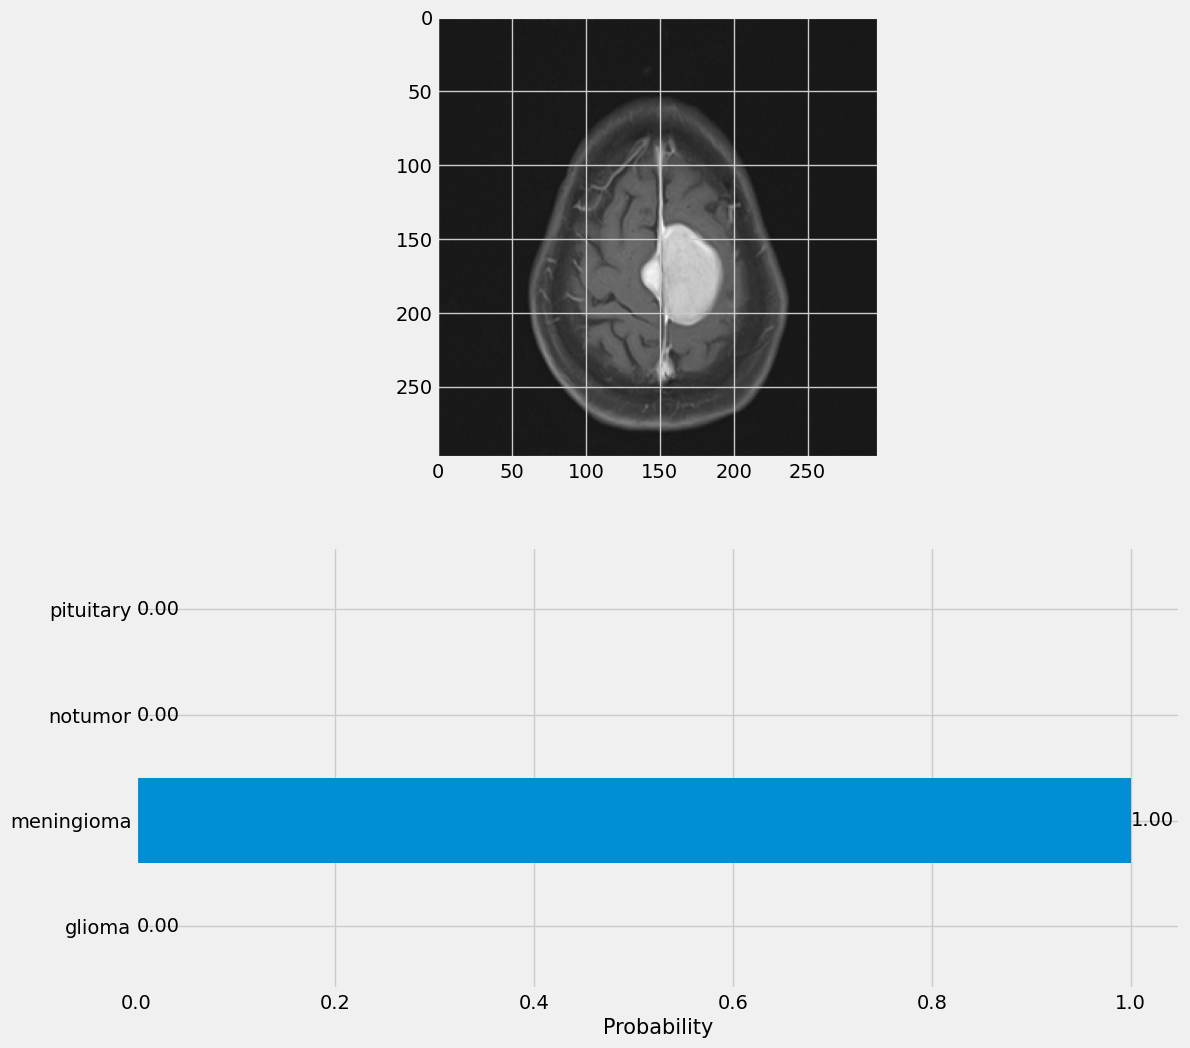

In [41]:
predict('bilaterialfalxmeningioma.jpeg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


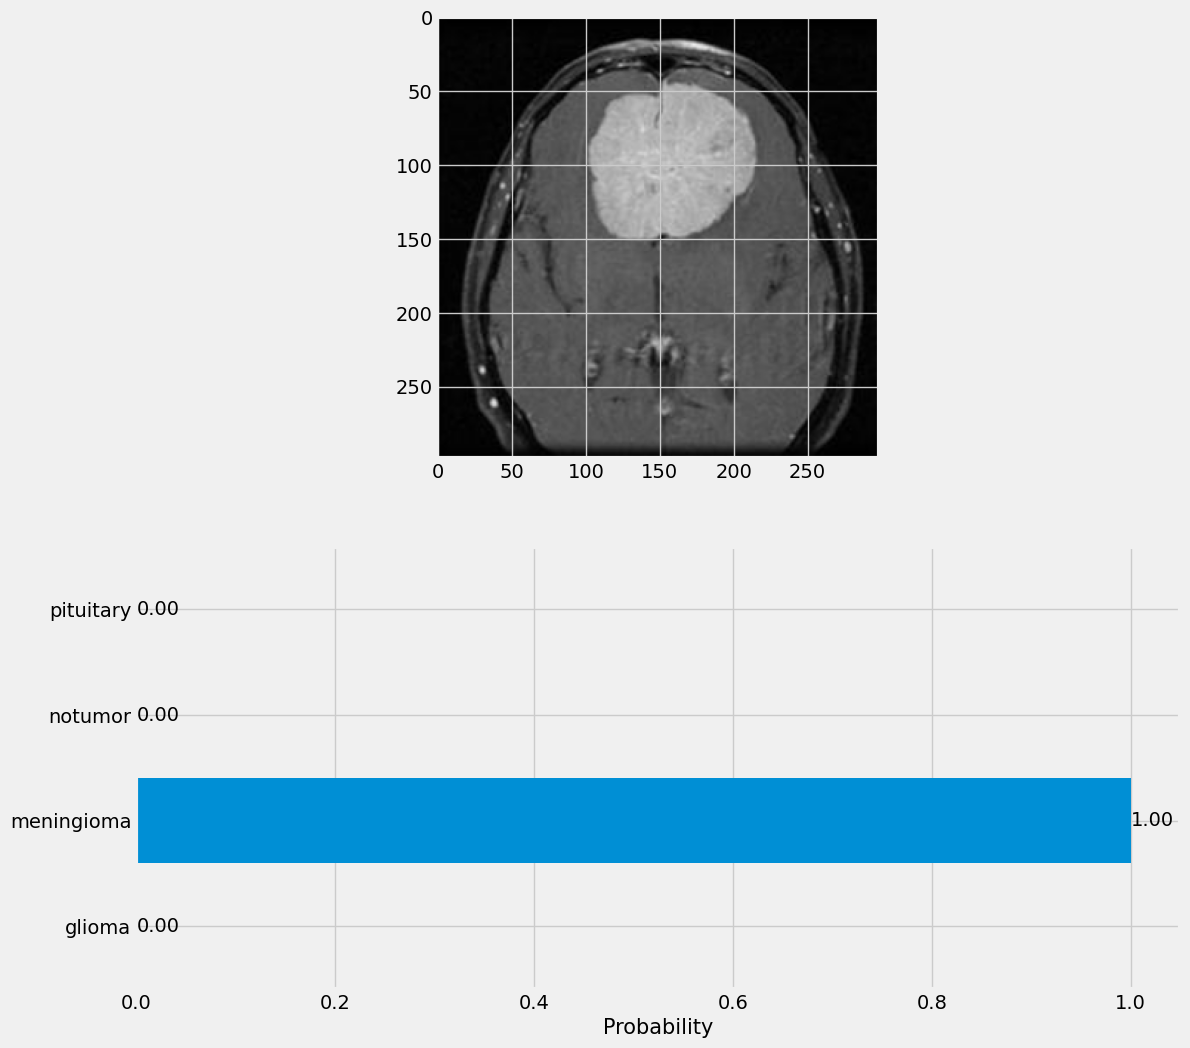

In [40]:
predict('olfactorygroovemeningioma.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


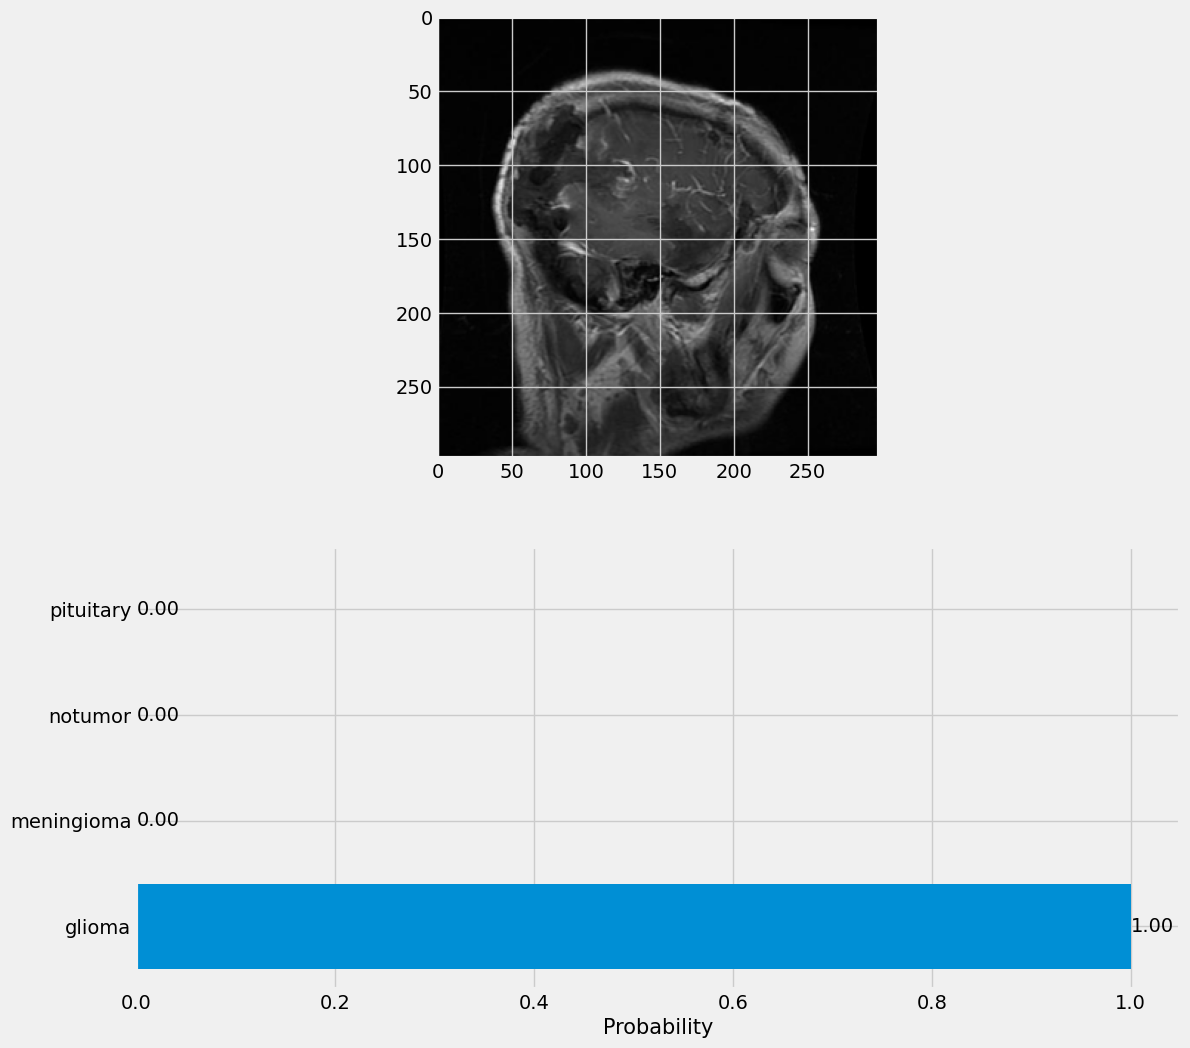

In [39]:
predict('./brain-tumor-mri-dataset/Testing/glioma/Te-gl_7.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


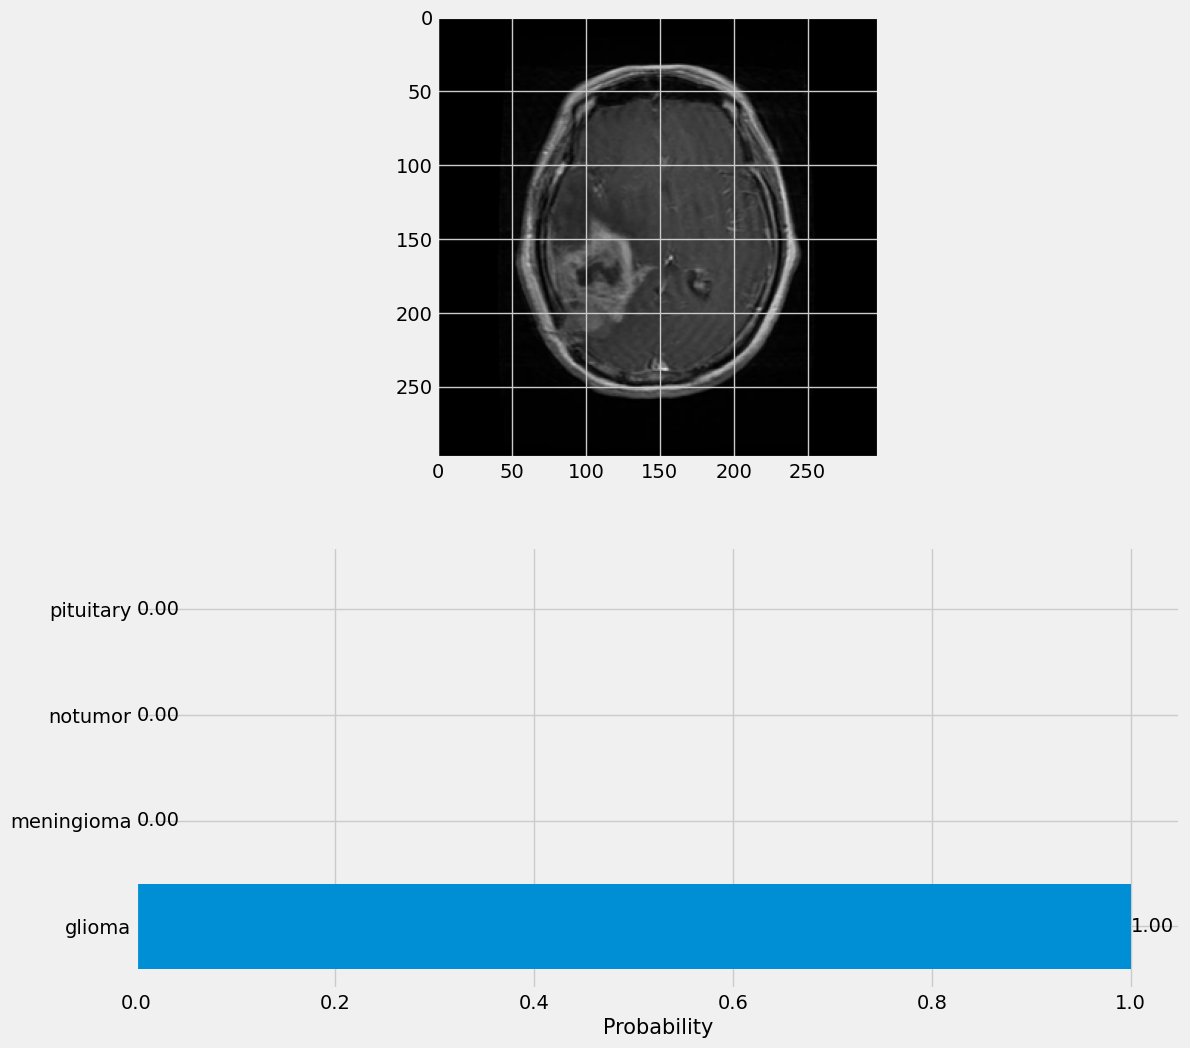

In [38]:
predict('./brain-tumor-mri-dataset/Testing/glioma/Te-gl_123.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


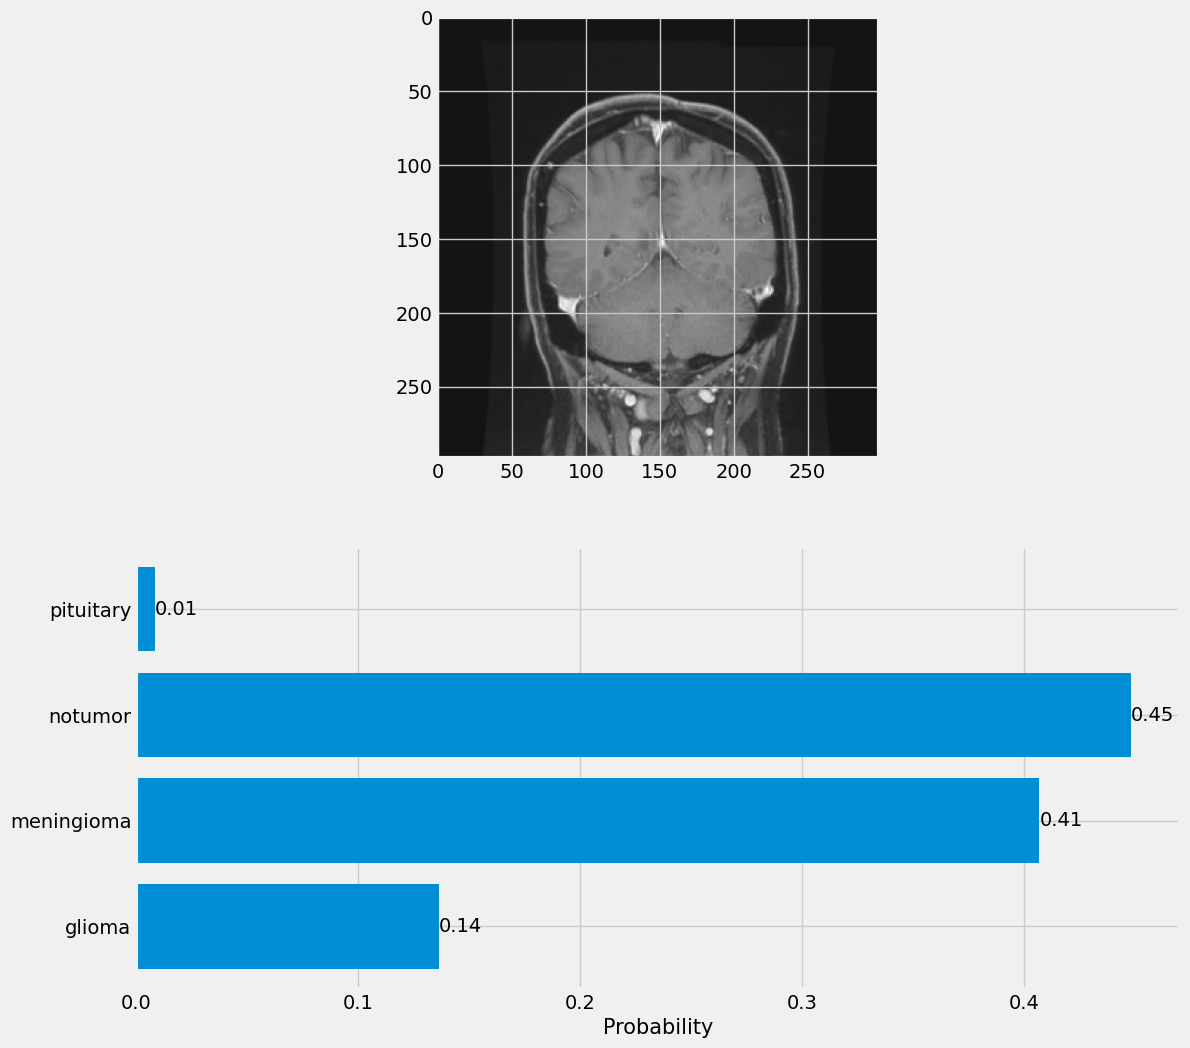

In [37]:
predict('gliomatosiscerebri.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


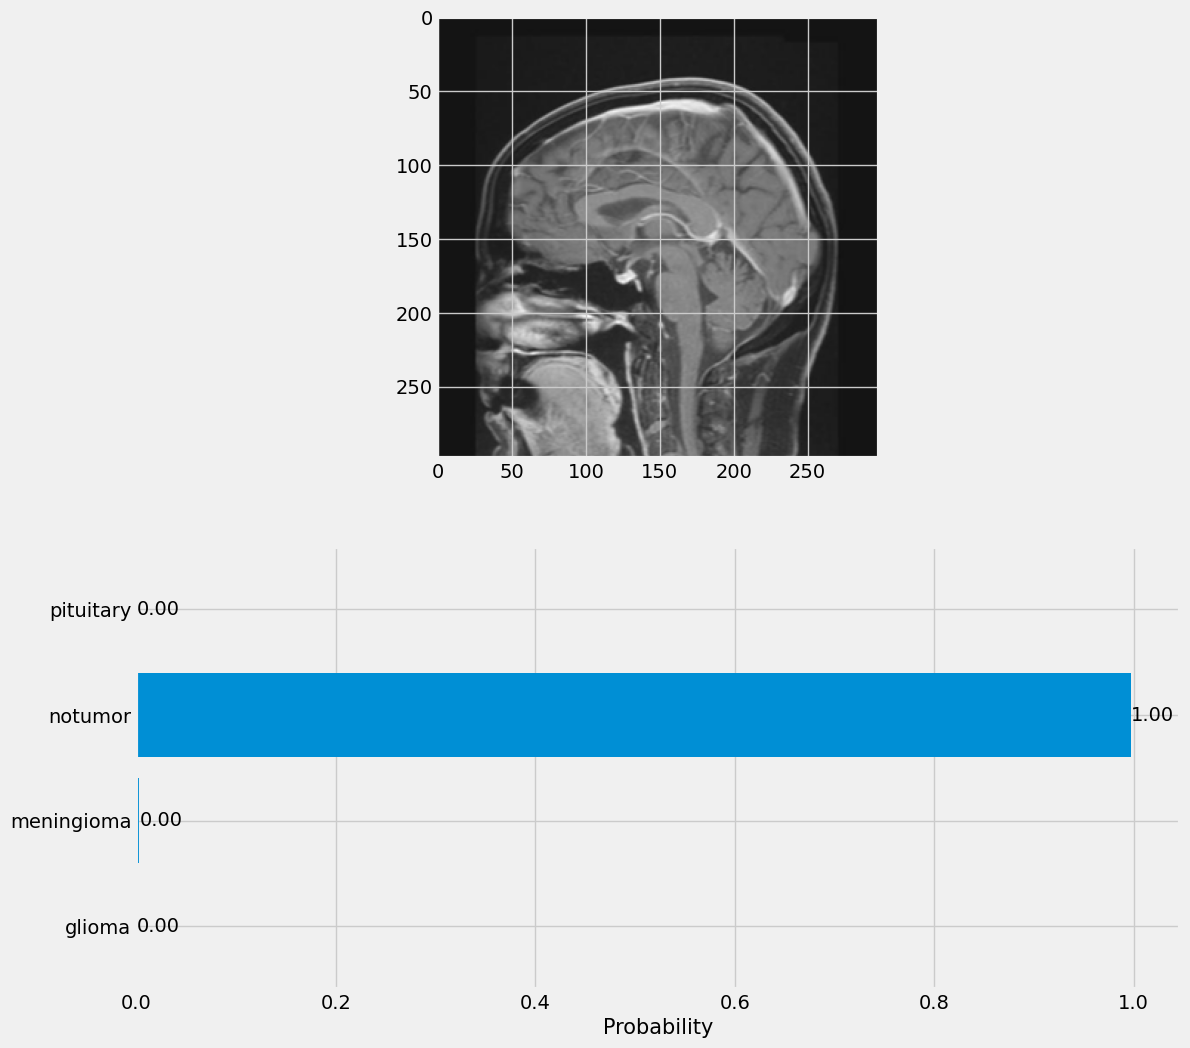

In [36]:
predict('gliomatosiscerebri2.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


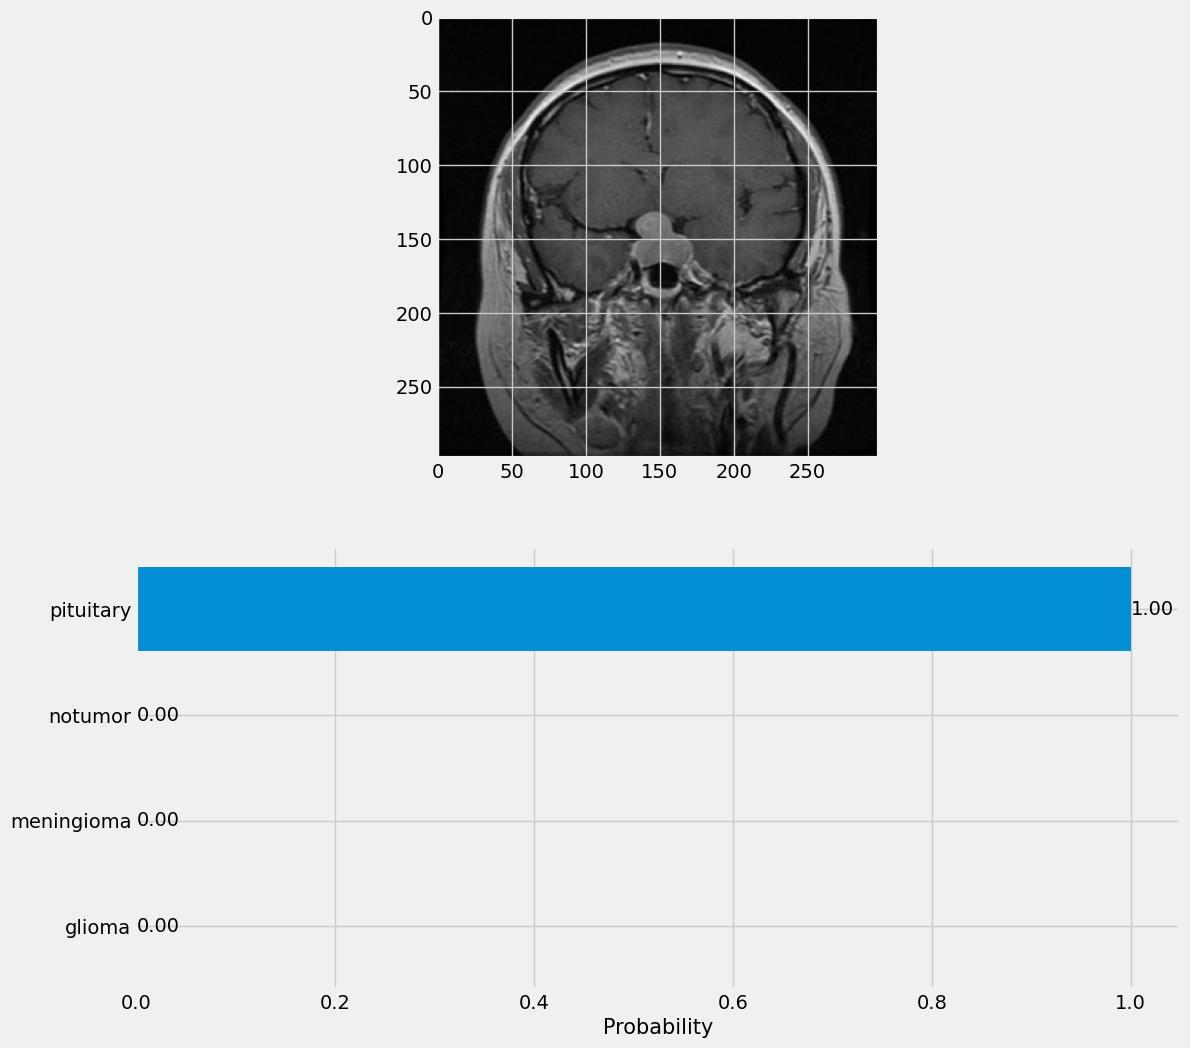

In [35]:
predict('./brain-tumor-mri-dataset/Testing/pituitary/Te-pi_107.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


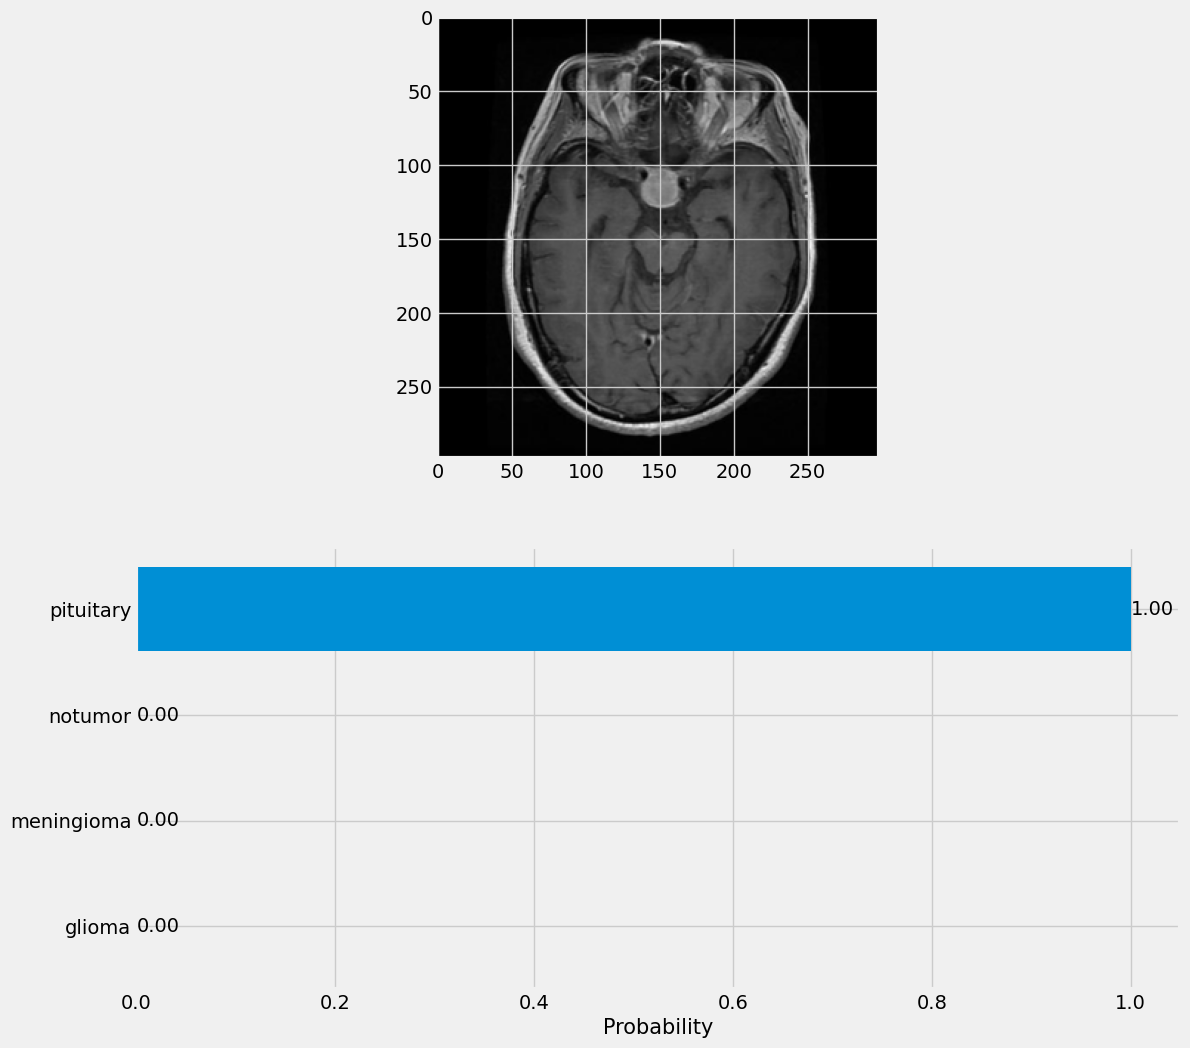

In [34]:
predict('./brain-tumor-mri-dataset/Testing/pituitary/Te-pi_119.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


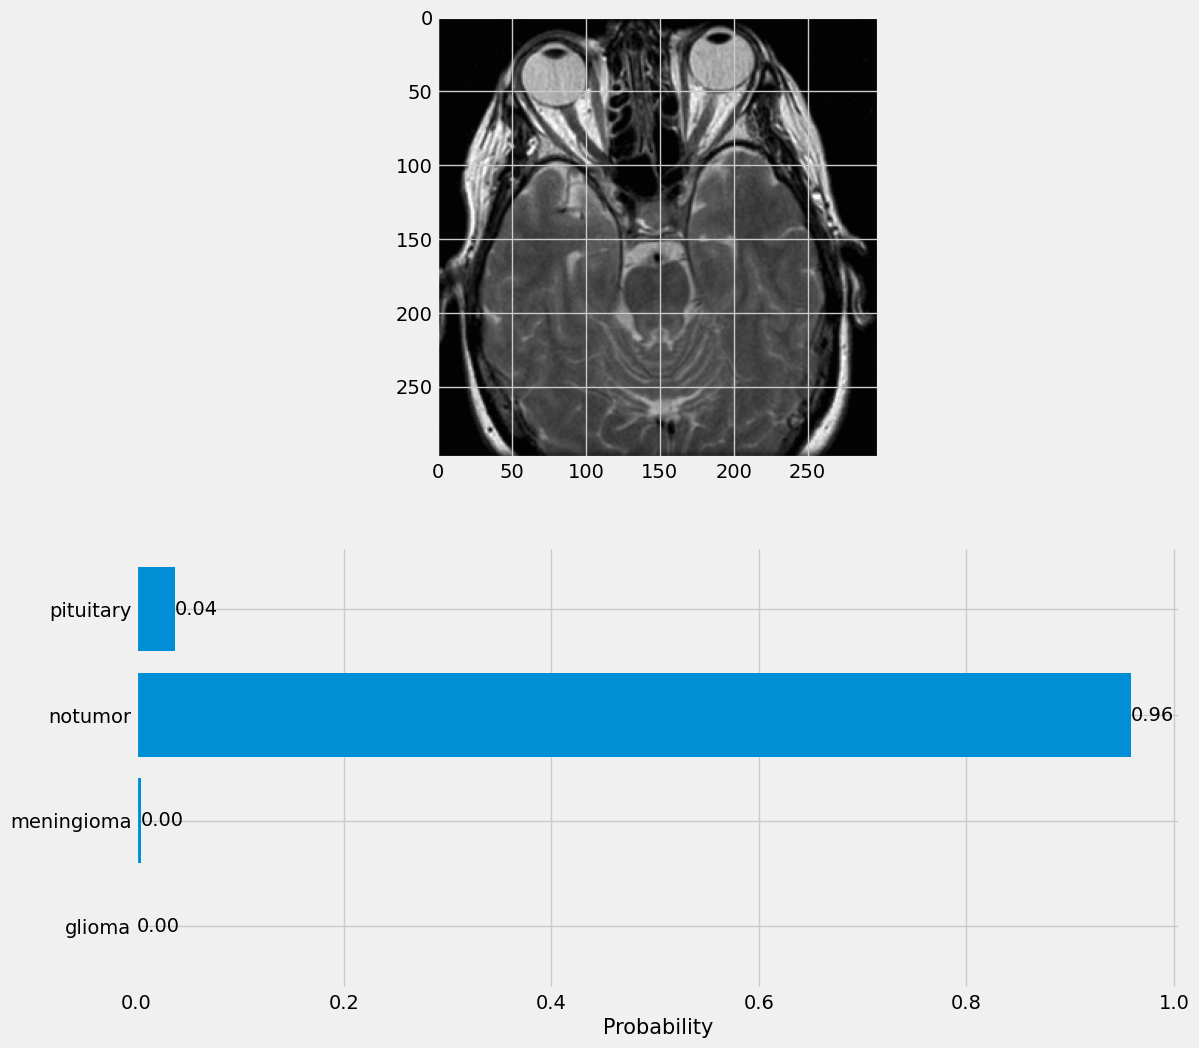

In [33]:
predict('pituicytoma.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


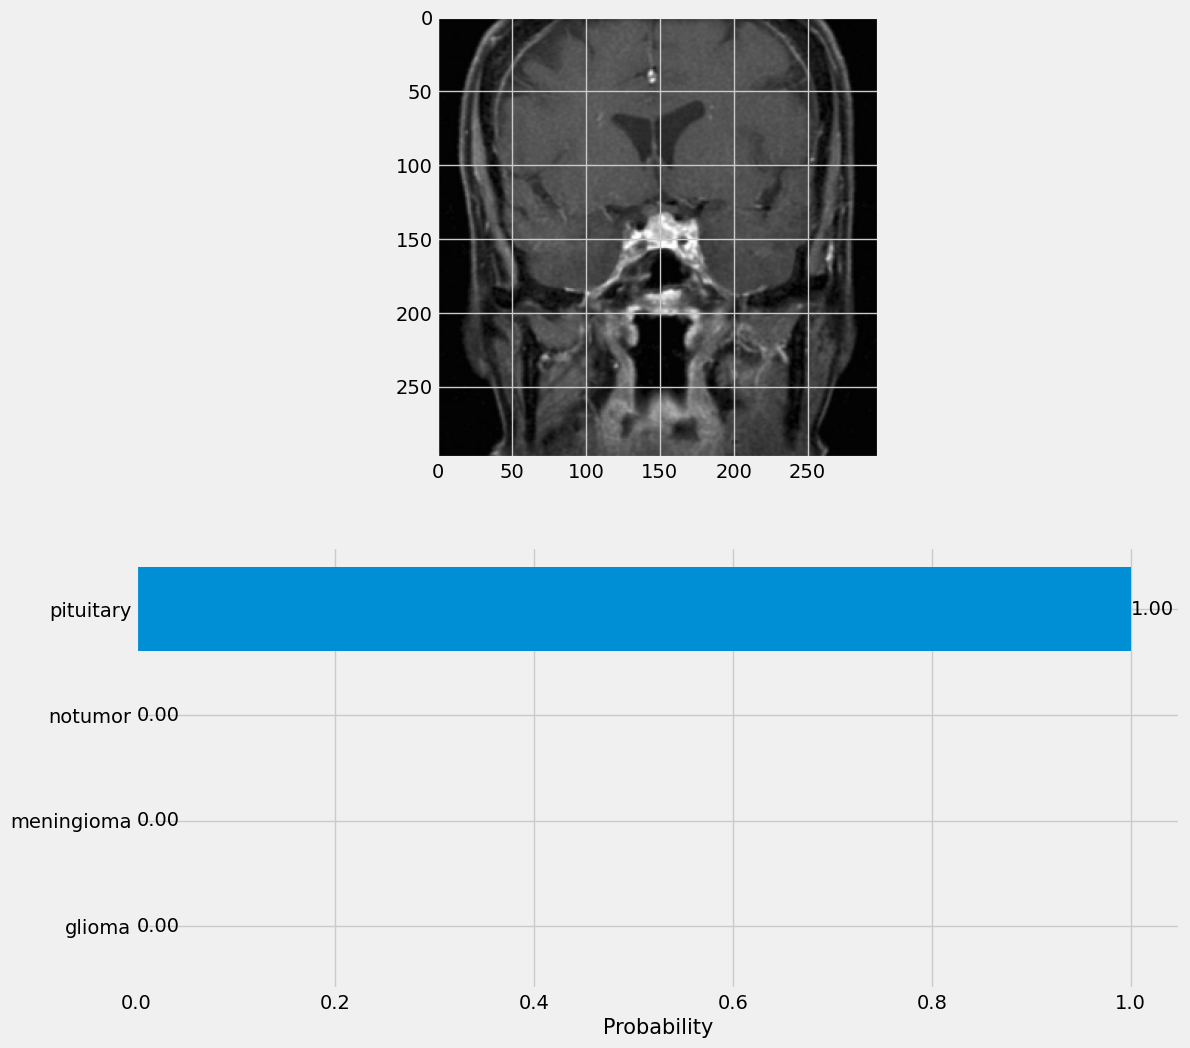

In [32]:
predict('pituitarymetastasis.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


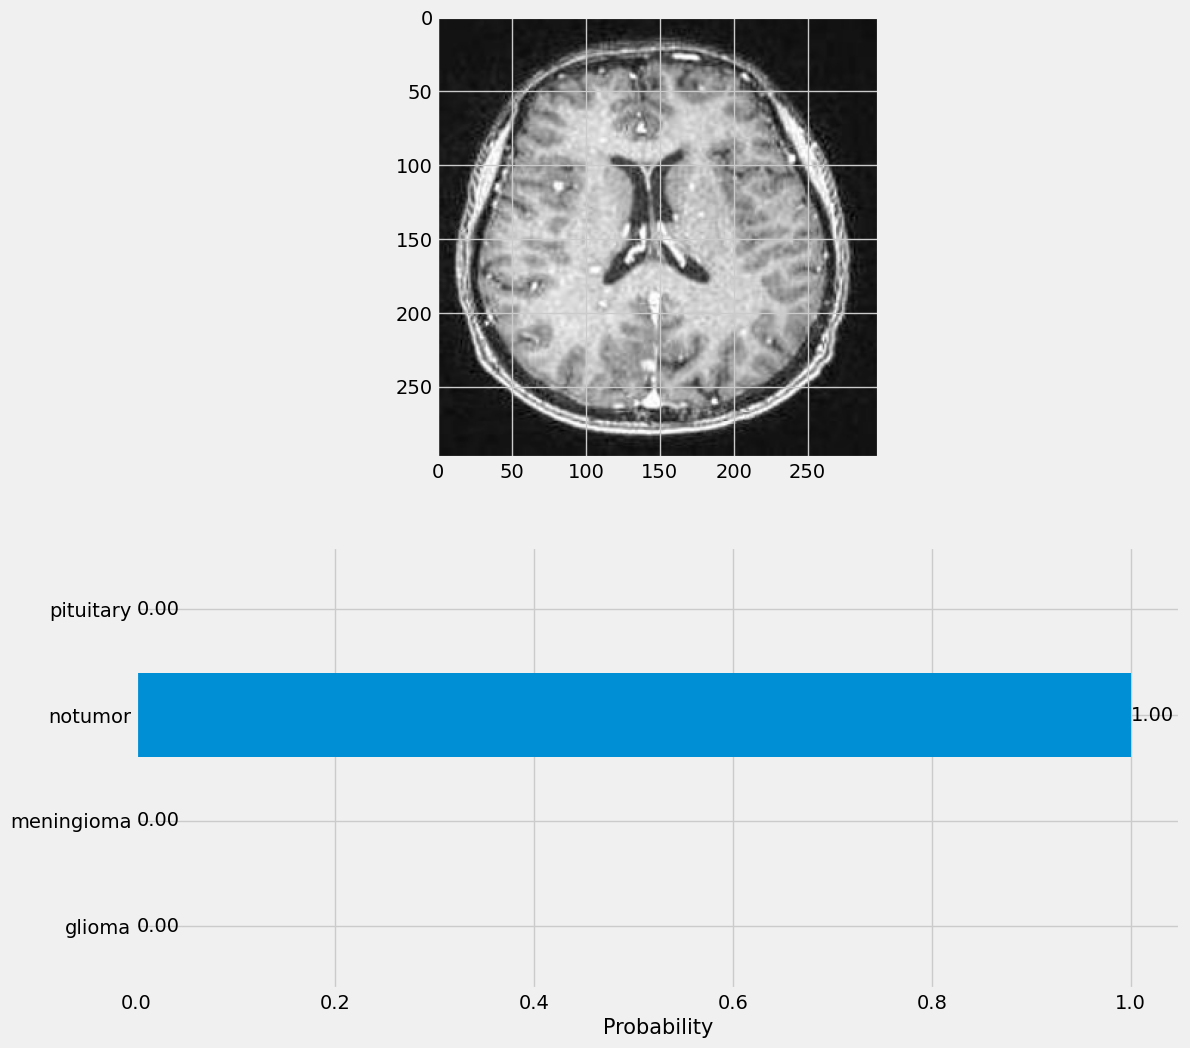

In [31]:
predict('./brain-tumor-mri-dataset/Testing/notumor/Te-no_120.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


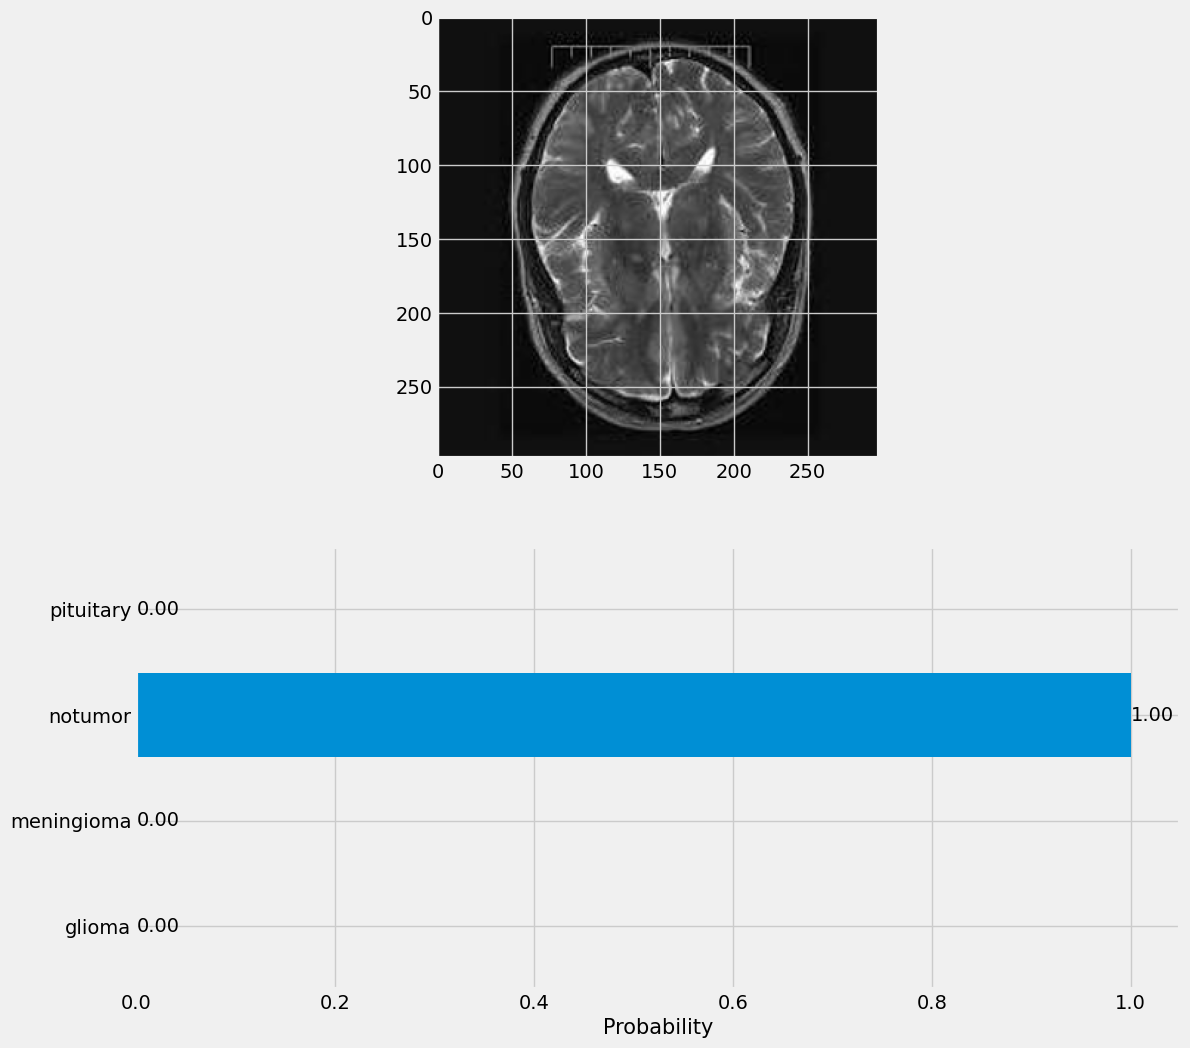

In [30]:
predict('./brain-tumor-mri-dataset/Testing/notumor/Te-no_112.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


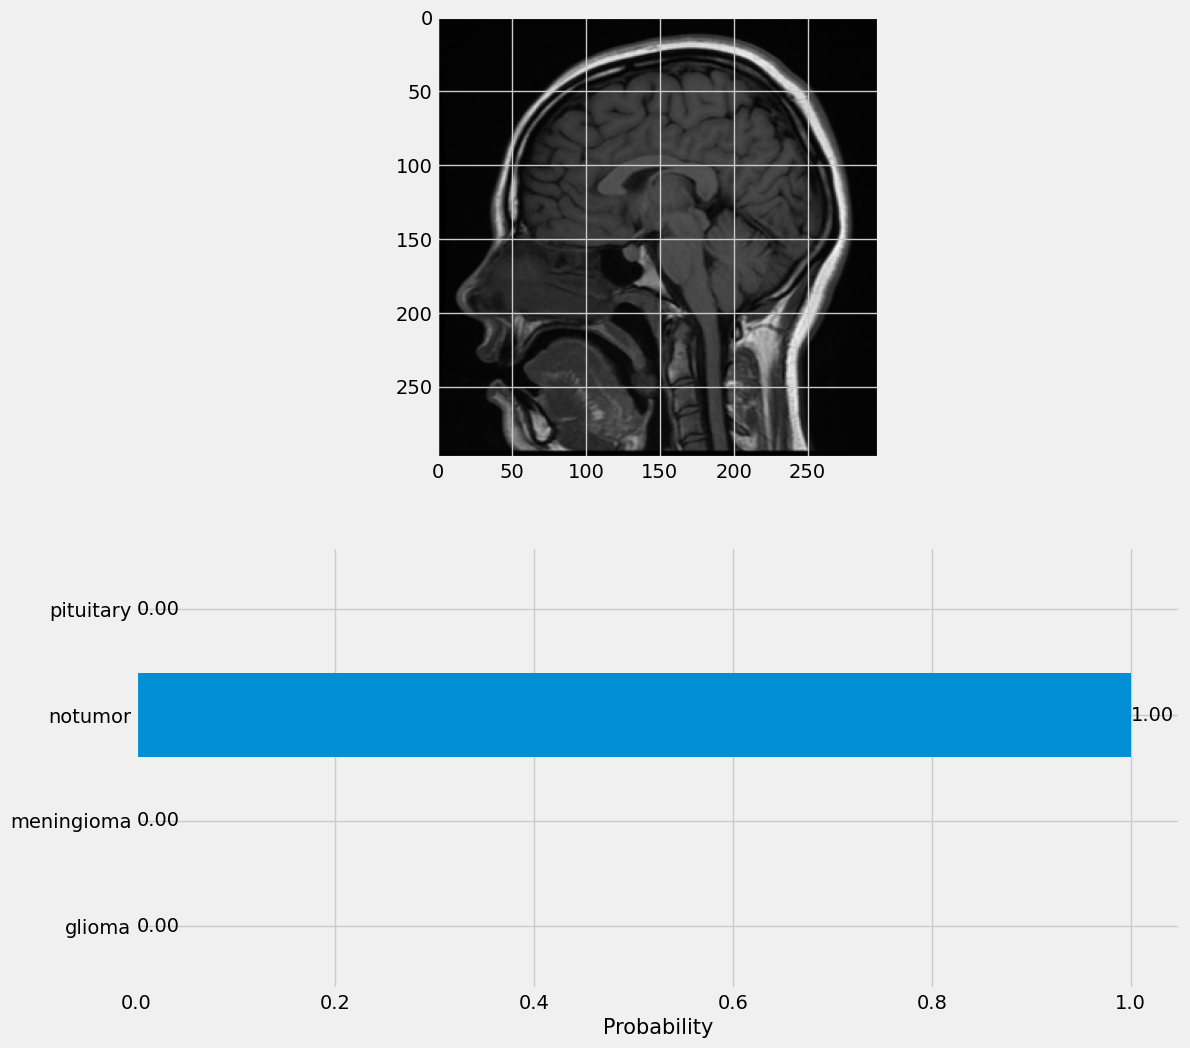

In [29]:
predict('normal1.png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


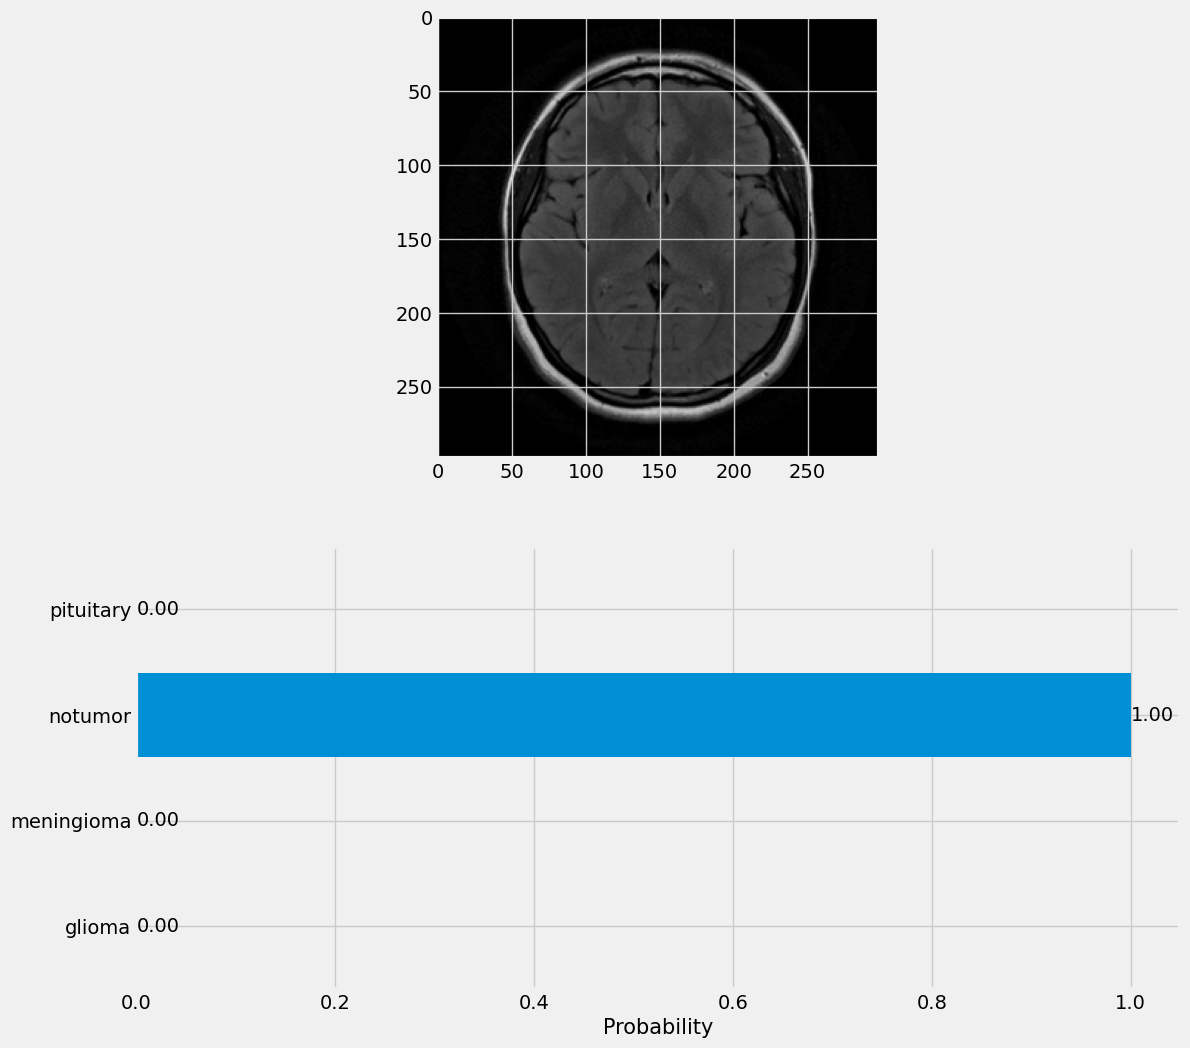

In [28]:
predict('normal2.png')